# Get the Data

In [22]:
import pandas as pd

df  = pd.read_csv("../../../datasets/spam.csv", encoding='latin-1')

In [23]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [30]:
print(f"The shape of the dataset it's: {df.shape}")

# So here we have 5572 samples

The shape of the dataset it's: (5572, 2)


# Preprocessing 

#### Remove the Unnamed Columns

In [24]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Encoding the target and the words

* **HAM:** Will be 0
* **SPAM:** Will be 1

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer

len = LabelEncoder()
df['v1'] = len.fit_transform(df['v1'])
y = df['v1']


# THE COUNT VECTORIZER WILL TRASNFORM ALL THE WORDS INTO A COLUMNS
# AND EACH SAMPLE FOR EACH COLUMNS WILL HAVE THE VALUES THAT WORD APPEARS IN THE SAMPLE
cv = CountVectorizer()
X = cv.fit_transform(df['v2'])

In [32]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [34]:
print(X.shape)

(5572, 8672)


# Split the data

In [38]:
# Check to see if the classes are well distribuited 

print(df[['v1']].value_counts())

v1
0     4825
1      747
Name: count, dtype: int64


In [40]:
print(X.shape, y.shape)

(5572, 8672) (5572,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.25, random_state=42, stratify=y)

In [44]:
print(f"Shape of train: {X_train.shape}, {y_train.shape}")
print(f"Shape of test: {X_test.shape}, {y_test.shape}")

Shape of train: (4179, 8672), (4179,)
Shape of test: (1393, 8672), (1393,)


# Get the model and the metrics

In [46]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mnb = MultinomialNB()


# Train the model

Train Metrics: Accuracy:0.994 | F1: 0.988 | Precision: 0.992 | Recall: 0.984|
Test Metrics: Accuracy:0.983 | F1: 0.963 | Precision: 0.959 | Recall: 0.967 | 
Confusion Matriz:


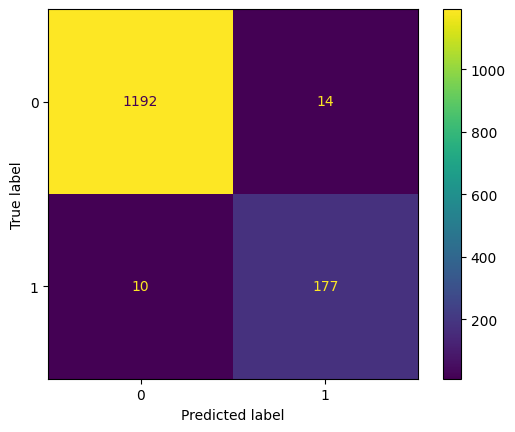

Best Parameters: {'alpha': 1.0, 'fit_prior': True}
Best Score (CV F1-Macro): 0.981


In [48]:
parameters = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 10.0],
    'fit_prior': [True, False]
}

grid = GridSearchCV(mnb, parameters, cv=5)
grid.fit(X_train, y_train)


# See the metrics (val test)
y_preds_train = grid.predict(X_train)
accuracy = accuracy_score(y_train, y_preds_train)
f1 = f1_score(y_train, y_preds_train, average = 'macro')
precision = precision_score(y_train, y_preds_train, average = 'macro')
recall = recall_score(y_train, y_preds_train, average = 'macro')
print(f"Train Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}|")

    # See the metrics (test set)
y_preds_test = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_preds_test)
f1 = f1_score(y_test, y_preds_test, average = 'macro')
precision = precision_score(y_test, y_preds_test, average = 'macro')
recall = recall_score(y_test, y_preds_test, average = 'macro')
confusion_m = ConfusionMatrixDisplay.from_predictions(y_test, y_preds_test)
print(f"Test Metrics: Accuracy:{accuracy:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | \nConfusion Matriz:")
plt.show()

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score (CV F1-Macro): {grid.best_score_:.3f}")




In [59]:
model = grid.best_estimator_


# Get new samples

In [58]:
# (HAM)
ham_tests = [
    "I'm on my way home, see you in 15 minutes.",
    "Can you send me the notes from yesterday's meeting?",
    "Dinner is ready, don't be late!",
    "Hey, did you see the Vasco game last night? What a match!",
    "Are we still on for coffee tomorrow at 10?"
]

# (SPAM)
spam_tests = [
    "WINNER! You have been selected for a $500 cash prize. Call 09061701461 to claim.",
    "Urgent! Your mobile number has won a free gift. Text 'GIFT' to 88066.",
    "Get the latest ringtones for free! Click the link below.",
    "PRIVATE! Your 2004 account for 07XXXXXXXXX shows un-redeemed points. Call now!",
    "Double your income working from home. No experience needed! Join us today."
]

In [67]:
print("Ham tests\n")
for text in ham_tests:
    text = cv.transform([text])
    predict = model.predict(text)
    if predict[0] == 0:
        print(f"You text is ham")
    else:
        print(f'You text is spam')

print('=' * 50)
print("Spam Tests\n")

for text in spam_tests:
    text = cv.transform([text])
    predict = model.predict(text)
    if predict[0] == 0:
        print(f"You text is ham")
    else:
        print(f'You text  spam')





Ham tests

You text is ham
You text is ham
You text is ham
You text is ham
You text is ham
Spam Tests

You text is spam
You text is spam
You text is spam
You text is spam
You text is ham


In [68]:
# Get the input and transform
user_input = input("Put your email text here: ")
user_input = cv.transform([user_input])

# Put the input in the model
user_model_predict = model.predict(user_input)

# See the predict
if user_model_predict[0] == 0:
    print(f"You text is ham")
else:
    print(f'You text is spam')


You text is ham


In [73]:
import joblib

# Salve the file for our app use
joblib.dump(model, 'model_nb.pkl') 


['model_nb.pkl']

In [74]:
joblib.dump(cv, 'vectorizer.pkl')

['vectorizer.pkl']